<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
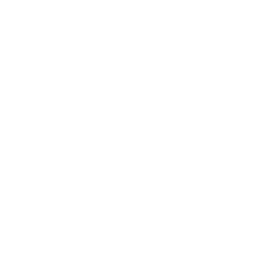
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Manufacturing Defect Category Prioritization</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Discrete Parts Manufacturing / Quality Engineering &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

A discrete-parts electronics line logs every board that fails final test, tagging each
failure with one of 14 defect codes grouped into four families: **Solder**, **Component**,
**Assembly**, and **Test**. This worked example takes a **100-record defect sample** drawn
across three production lines (LINE-A, LINE-B, LINE-C) and uses **PROC PARETO** to separate
the *vital few* defect codes from the *trivial many*.

Two views are compared. A **count-based** Pareto ranks defect codes by how *often* they occur:
the solder family leads, with `SLD-01`, `SLD-02`, and `SLD-03` together accounting for **43%**
of all defects. A **cost-weighted** Pareto re-ranks the same codes by total **rework dollars**:
`TST-01` (Functional Fail - Power), at \$45 per repair, jumps from a mid-pack 10-defect code
to the **single largest cost driver at 25.3%** of all rework spend, even though it is only 10%
of the defect count. Splitting the cost Pareto **by production line** then exposes line-specific
excursions that the aggregate view hides — most sharply, LINE-B's rework cost is **38.6%**
`TST-01` alone, while LINE-C carries **no functional-test failures at all**.

## Data

A 100-row defect sample is generated with a fixed seed (`streaminit(42)`) so the analysis is
fully reproducible. Each record carries a defect code, its family, the production line, and a
standard rework cost looked up from a small reference catalog. The defect mix follows a
realistic Pareto shape, with two deliberately injected line excursions: LINE-C runs hot on
solder defects, and LINE-B (along with LINE-A) carries elevated functional-test failures.

| Dataset | Description | Rows |
|---------|-------------|------|
| `WORK.DEFECT_CATALOG` | Defect code reference with standard rework cost and repair time | 14 |
| `WORK.DEFECT_RECORDS` | Individual board failure records across three lines | 100 |

> This environment runs Jenner in unlicensed mode, which caps output at 100 observations.
> The sample is sized to that cap; every number quoted below comes from the 100-record run
> shown in the cell outputs.

---

In [1]:
/* --------------------------------------------------------
   Defect code reference catalog with standard rework cost
   -------------------------------------------------------- */
data work.defect_catalog;
    length defect_code $6 defect_description $35 defect_family $20;
    infile datalines dsd;
    input defect_code $ defect_description $
          defect_family $ rework_cost_usd repair_time_min;
    datalines;
SLD-01,Solder Bridge,Solder,12.50,8
SLD-02,Insufficient Solder,Solder,9.75,6
SLD-03,Solder Ball,Solder,7.25,5
SLD-04,Cold Solder Joint,Solder,14.00,10
CMP-01,Missing Component,Component,22.00,15
CMP-02,Wrong Component,Component,28.50,20
CMP-03,Tombstone Component,Component,18.00,12
CMP-04,Lifted Lead,Component,16.50,11
ASM-01,PCB Scratch,Assembly,8.00,4
ASM-02,Contamination,Assembly,11.25,7
ASM-03,Bent Pin,Assembly,13.75,9
TST-01,Functional Fail - Power,Test,45.00,35
TST-02,Functional Fail - Comm,Test,38.00,28
TST-03,Parametric Out of Spec,Test,31.00,22
;
run;

NOTE: DATA work.defect_catalog

NOTE: Processing inline DATALINES (14 lines)

NOTE: Read 14 rows from DATALINES.
NOTE: Wrote work.defect_catalog (14 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [2]:
/* --------------------------------------------------------
   100-record defect sample across 3 production lines.
   Defect mix follows a Pareto shape with two injected
   line excursions:
     - LINE-C runs hot on solder defects (codes 1-4)
     - LINE-A/LINE-B carry elevated functional-test fails
   Rework cost is looked up from the catalog via a hash.
   -------------------------------------------------------- */
data work.defect_records;
    call streaminit(42);
    if _n_ = 1 then do;
        declare hash hcat(dataset: 'work.defect_catalog');
        hcat.definekey('defect_code');
        hcat.definedata('defect_description', 'defect_family',
                        'rework_cost_usd', 'repair_time_min');
        hcat.definedone();
    end;
    length defect_id $14 defect_code $6 defect_description $35
           defect_family $20 production_line $8;
    array codes[14] $6 _temporary_ (
        'SLD-01' 'SLD-02' 'SLD-03' 'SLD-04'
        'CMP-01' 'CMP-02' 'CMP-03' 'CMP-04'
        'ASM-01' 'ASM-02' 'ASM-03'
        'TST-01' 'TST-02' 'TST-03');
    /* Base defect-mix weights (Pareto shape) */
    array base_wts[14] _temporary_ (
        0.19 0.14 0.10 0.09
        0.12 0.07 0.05 0.04
        0.06 0.05 0.04
        0.08 0.06 0.05);
    do rec_num = 1 to 100;
        defect_id = cat('DEF-', put(rec_num, z7.));
        /* Assign production line */
        r_line = rand('uniform');
        if r_line < 0.40 then production_line = 'LINE-A';
        else if r_line < 0.70 then production_line = 'LINE-B';
        else production_line = 'LINE-C';
        /* Select defect code with line-specific excursions */
        r_def = rand('uniform');
        cumwt = 0; def_idx = 14;
        do k = 1 to 14;
            if production_line = 'LINE-C' and k <= 4 then
                adj_wt = base_wts[k] * 1.7;          /* solder excursion */
            else if production_line = 'LINE-B' and k in (5, 6, 7, 8) then
                adj_wt = base_wts[k] * 1.5;          /* component excursion */
            else
                adj_wt = base_wts[k];
            cumwt + adj_wt;
            if r_def <= cumwt / 1.18 and def_idx = 14 then def_idx = k;
        end;
        defect_code = codes[def_idx];
        /* Look up description and cost from the catalog */
        rc = hcat.find();
        if rc ne 0 then do;
            defect_description = 'Unknown';
            defect_family = 'Unknown';
            rework_cost_usd = 0; repair_time_min = 0;
        end;
        qty_defective = 1;
        output;
    end;
    drop rec_num r_line r_def cumwt def_idx k adj_wt rc;
run;

NOTE: DATA work.defect_records


NOTE: Wrote work.defect_records (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


### Baseline: where do the defects and the costs sit?

Before any Pareto, a quick cross-tab and cost summary frame the problem. The family-by-line
table shows **Solder** is the most common family (51 of 100 defects), while the cost summary
shows the **Test** family — only 12 defects — carries the **highest mean rework cost (\$43.25)**
and the second-highest total (\$519). That gap between *frequency* and *cost* is exactly what
the cost-weighted Pareto below is built to expose.

                                       Baseline: Defect Family by Production Line                                       

                                                   The FREQ Procedure

Table of DEFECT_FAMILY by PRODUCTION_LINE

DEFECT_FAMILY |    LINE-A |    LINE-B |    LINE-C |      Total
--------------+-----------+-----------+-----------+-----------
Assembly      |         7 |         4 |         0 |         11
--------------+-----------+-----------+-----------+-----------
Component     |        14 |         8 |         4 |         26
--------------+-----------+-----------+-----------+-----------
Solder        |        19 |        16 |        16 |         51
--------------+-----------+-----------+-----------+-----------
Test          |         5 |         7 |         0 |         12
--------------+-----------+-----------+-----------+-----------
Total         |        45 |        35 |        20 |        100

                                    Baseline: Rework Cost and Time by 

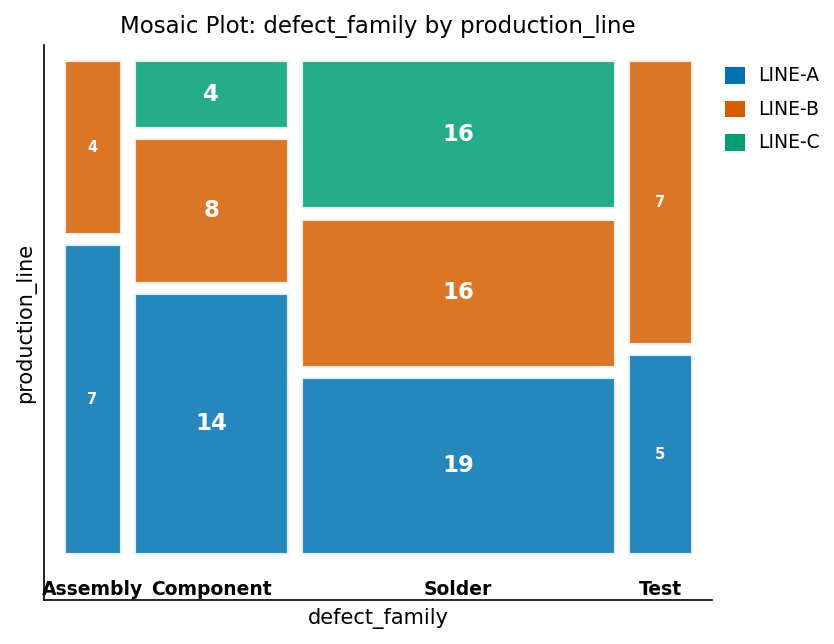

In [3]:
/* --------------------------------------------------------
   Baseline: defect family by line, and cost by family
   -------------------------------------------------------- */
proc freq data=work.defect_records;
    tables defect_family * production_line / nocol nopercent;
    title 'Baseline: Defect Family by Production Line';
run;

proc means data=work.defect_records n sum mean maxdec=2;
    class defect_family;
    var rework_cost_usd repair_time_min;
    title 'Baseline: Rework Cost and Time by Defect Family';
run;

---

### Step 1 — Count-based Pareto (all lines)

The first Pareto ranks defect **codes by frequency**. `OTHERPCT=3` folds any code under 3% of
volume into an *Other* bucket so the chart stays legible. The vital few by count are the solder
codes: `SLD-01` (18), `SLD-02` (13), and `SLD-03` (12) lead, and the cumulative line crosses
**80% at `SLD-04`** — six of fourteen codes explain four-fifths of all defects.

                                    Baseline: Rework Cost and Time by Defect Family                                     


                    The PARETO Procedure

  Category                  Count    Percent Cumulative %
  -------------------- ---------- ---------- ------------
  SLD-01                     18.0      18.0%        18.0%
  SLD-02                     13.0      13.0%        31.0%
  SLD-03                     12.0      12.0%        43.0%
  CMP-01                     10.0      10.0%        53.0%
  CMP-02                     10.0      10.0%        63.0%
  TST-01                     10.0      10.0%        73.0%
  SLD-04                      8.0       8.0%        81.0%
  ASM-01                      7.0       7.0%        88.0%
  ASM-02                      4.0       4.0%        92.0%
  CMP-03                      4.0       4.0%        96.0%
  CMP-04                      2.0       2.0%        98.0%
  TST-02                      1.0       1.0%        99.0%
  TST-03               

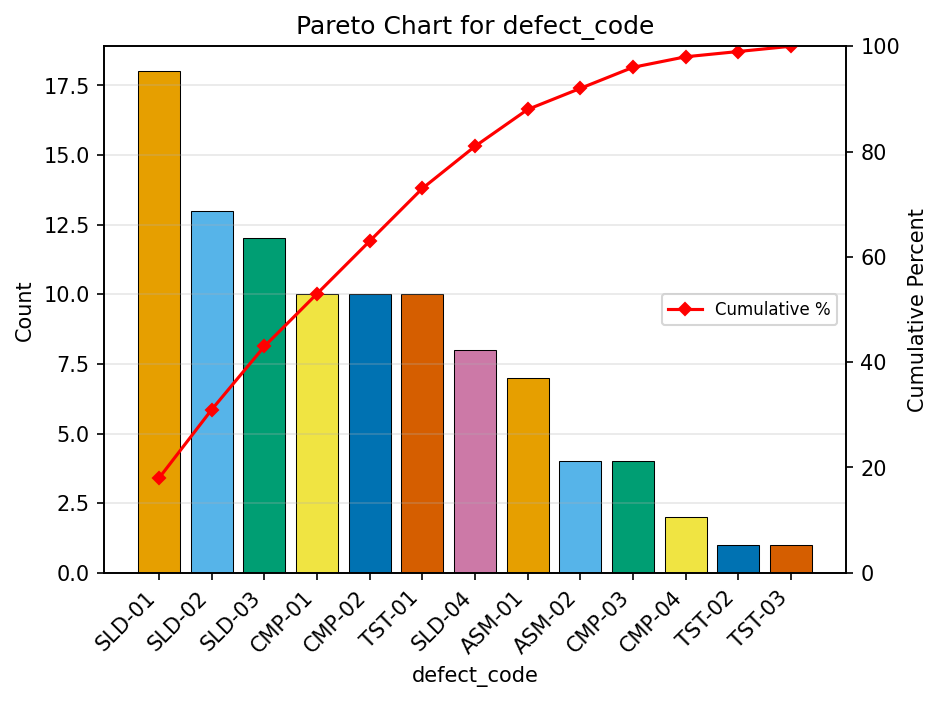

In [4]:
/* --------------------------------------------------------
   Step 1: Count-based Pareto across all lines
   -------------------------------------------------------- */
proc pareto data=work.defect_records;
    vbar defect_code / otherpct = 3;
    title 'Pareto Chart: Defect Codes by Count (All Lines)';
run;

### Step 2 — Cost-weighted Pareto (all lines)

Re-running the Pareto with `WEIGHT=rework_cost_usd` ranks the same codes by **total rework
dollars** instead of count. The priority list reorders sharply: `TST-01` (Functional Fail -
Power) moves to **first place at 25.3%** of all rework cost despite being only the sixth most
*frequent* code, because each `TST-01` repair costs \$45. `CMP-02` (\$28.50) follows at 16.0%.
The top four cost drivers — `TST-01`, `CMP-02`, `SLD-01`, `CMP-01` — account for **66%** of
rework spend. This is the central insight of the analysis: *fixing the most common defect is
not the same as fixing the most expensive one.*

                                    Baseline: Rework Cost and Time by Defect Family                                     


                    The PARETO Procedure

  Category                  Count    Percent Cumulative %
  -------------------- ---------- ---------- ------------
  TST-01                    450.0      25.3%        25.3%
  CMP-02                    285.0      16.0%        41.3%
  SLD-01                    225.0      12.6%        53.9%
  CMP-01                    220.0      12.4%        66.3%
  SLD-02                    126.8       7.1%        73.4%
  SLD-04                    112.0       6.3%        79.7%
  SLD-03                     87.0       4.9%        84.6%
  CMP-03                     72.0       4.0%        88.6%
  ASM-01                     56.0       3.1%        91.7%
  ASM-02                     45.0       2.5%        94.3%
  TST-02                     38.0       2.1%        96.4%
  CMP-04                     33.0       1.9%        98.3%
  TST-03               

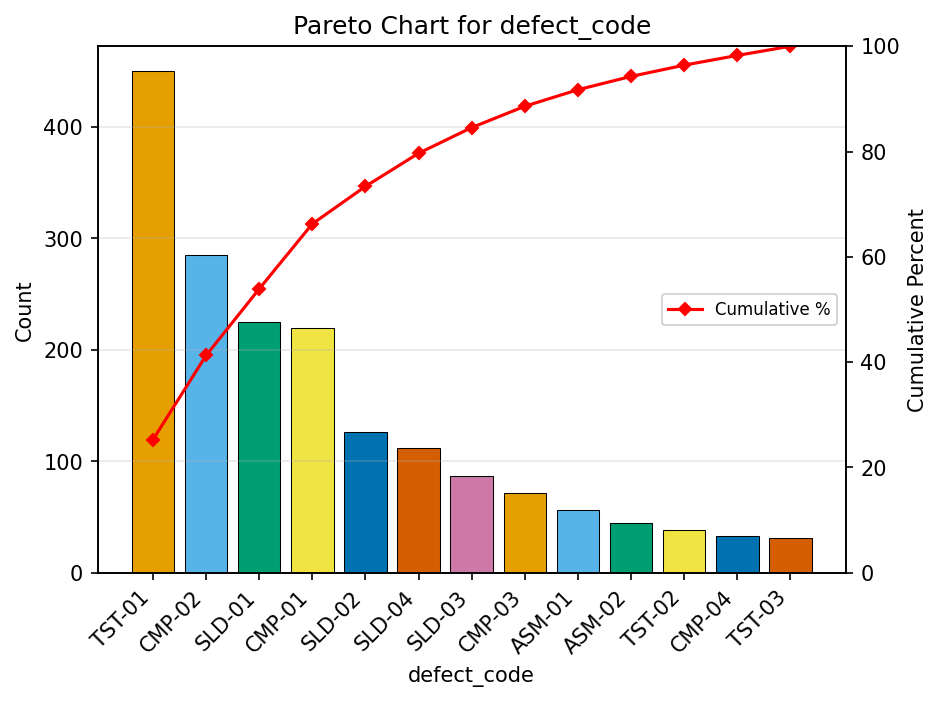

In [5]:
/* --------------------------------------------------------
   Step 2: Cost-weighted Pareto — rework dollars per code.
   WEIGHT shifts priority toward expensive defect types
   even when their count is modest.
   -------------------------------------------------------- */
proc pareto data=work.defect_records;
    vbar defect_code / weight = rework_cost_usd
                       otherpct = 3;
    title 'Pareto Chart: Defect Codes by Rework Cost (All Lines)';
run;

### Step 3 — Cost-weighted Pareto by production line

Running a separate cost Pareto for each line reveals excursions the aggregate view masks. Each
line is charted in its own cell so all three are visible:

- **LINE-A** — broad mix led by `TST-01` (22.2%) and `CMP-02` (17.6%); no single dominant code.
- **LINE-B** — a stark single-defect excursion: `TST-01` alone is **38.6%** of the line's rework
  cost, pointing at a power-test or firmware-load problem specific to that line.
- **LINE-C** — a completely different signature: `CMP-02` (31.4%) plus four solder codes, and
  **zero Test-family failures** — consistent with the injected solder excursion and a clean
  functional-test station.

                                    Baseline: Rework Cost and Time by Defect Family                                     


                    The PARETO Procedure

  Category                  Count    Percent Cumulative %
  -------------------- ---------- ---------- ------------
  TST-01                    180.0      22.2%        22.2%
  CMP-02                    142.5      17.6%        39.8%
  SLD-01                    112.5      13.9%        53.7%
  CMP-01                    110.0      13.6%        67.3%
  SLD-02                     58.5       7.2%        74.5%
  CMP-03                     54.0       6.7%        81.2%
  ASM-02                     45.0       5.6%        86.8%
  TST-03                     31.0       3.8%        90.6%
  ASM-01                     24.0       3.0%        93.5%
  SLD-03                     21.8       2.7%        96.2%
  CMP-04                     16.5       2.0%        98.3%
  SLD-04                     14.0       1.7%       100.0%
  -------------------- 

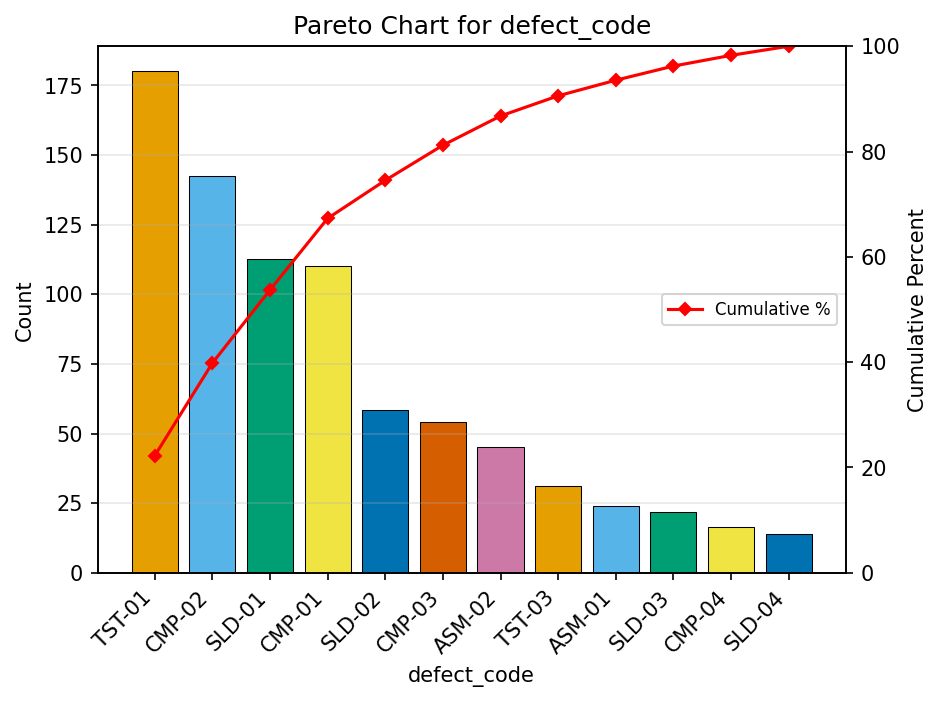

In [6]:
/* --------------------------------------------------------
   Step 3.A: Cost-weighted Pareto for LINE-A (broad cost mix).
   Subset to the line with a DATA step first, then chart —
   each line then renders as its own distinct Pareto.
   -------------------------------------------------------- */
data work.line_a;
    set work.defect_records;
    where production_line = 'LINE-A';
run;

proc pareto data=work.line_a;
    vbar defect_code / weight = rework_cost_usd
                       otherpct = 5;
    title 'Pareto Chart: Rework Cost by Defect Code — LINE-A';
run;

                                    Baseline: Rework Cost and Time by Defect Family                                     


                    The PARETO Procedure

  Category                  Count    Percent Cumulative %
  -------------------- ---------- ---------- ------------
  TST-01                    270.0      38.6%        38.6%
  CMP-01                     88.0      12.6%        51.2%
  SLD-01                     75.0      10.7%        61.9%
  CMP-02                     57.0       8.2%        70.1%
  SLD-04                     56.0       8.0%        78.1%
  TST-02                     38.0       5.4%        83.5%
  ASM-01                     32.0       4.6%        88.1%
  SLD-03                     29.0       4.1%        92.3%
  SLD-02                     19.5       2.8%        95.1%
  CMP-03                     18.0       2.6%        97.6%
  CMP-04                     16.5       2.4%       100.0%
  -------------------- ----------
  Total                     699.0


NOTE: DATA 

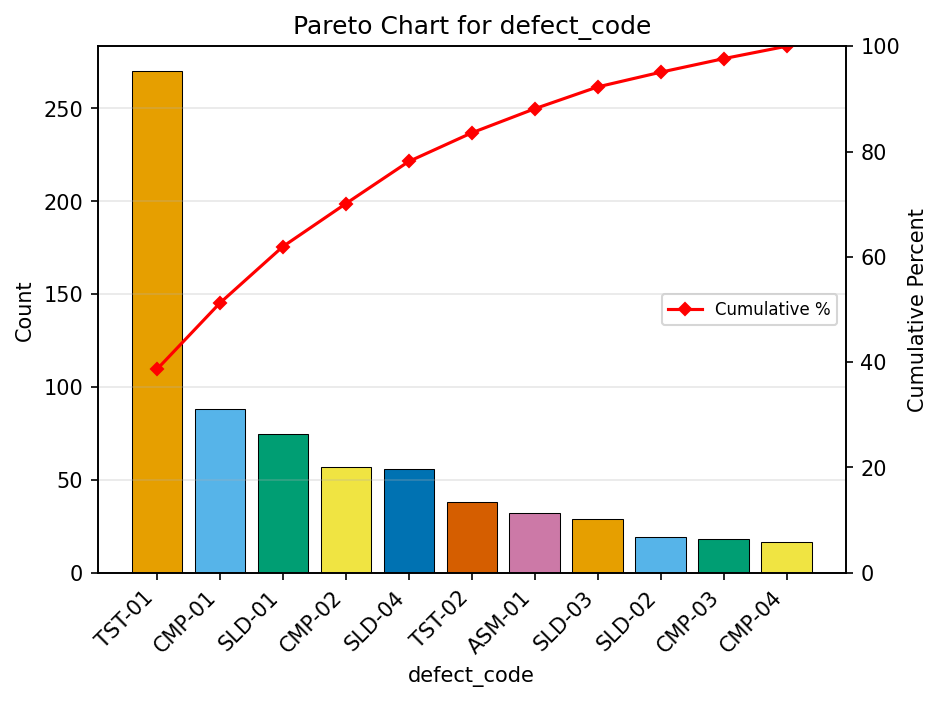

In [7]:
/* --------------------------------------------------------
   Step 3.B: Cost-weighted Pareto for LINE-B (TST-01 cost excursion (38.6%)).
   Subset to the line with a DATA step first, then chart —
   each line then renders as its own distinct Pareto.
   -------------------------------------------------------- */
data work.line_b;
    set work.defect_records;
    where production_line = 'LINE-B';
run;

proc pareto data=work.line_b;
    vbar defect_code / weight = rework_cost_usd
                       otherpct = 5;
    title 'Pareto Chart: Rework Cost by Defect Code — LINE-B';
run;

                                    Baseline: Rework Cost and Time by Defect Family                                     


                    The PARETO Procedure

  Category                  Count    Percent Cumulative %
  -------------------- ---------- ---------- ------------
  CMP-02                     85.5      31.4%        31.4%
  SLD-02                     48.8      17.9%        49.4%
  SLD-04                     42.0      15.4%        64.8%
  SLD-01                     37.5      13.8%        78.6%
  SLD-03                     36.2      13.3%        91.9%
  CMP-01                     22.0       8.1%       100.0%
  -------------------- ----------
  Total                     272.0


NOTE: DATA work.line_c


NOTE: Read 100 rows from work.defect_records.
NOTE: Wrote work.line_c (20 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PARETO
NOTE: ODS plot written: pareto_defect_code.spec.json
NOTE: PROC PARETO statement used.


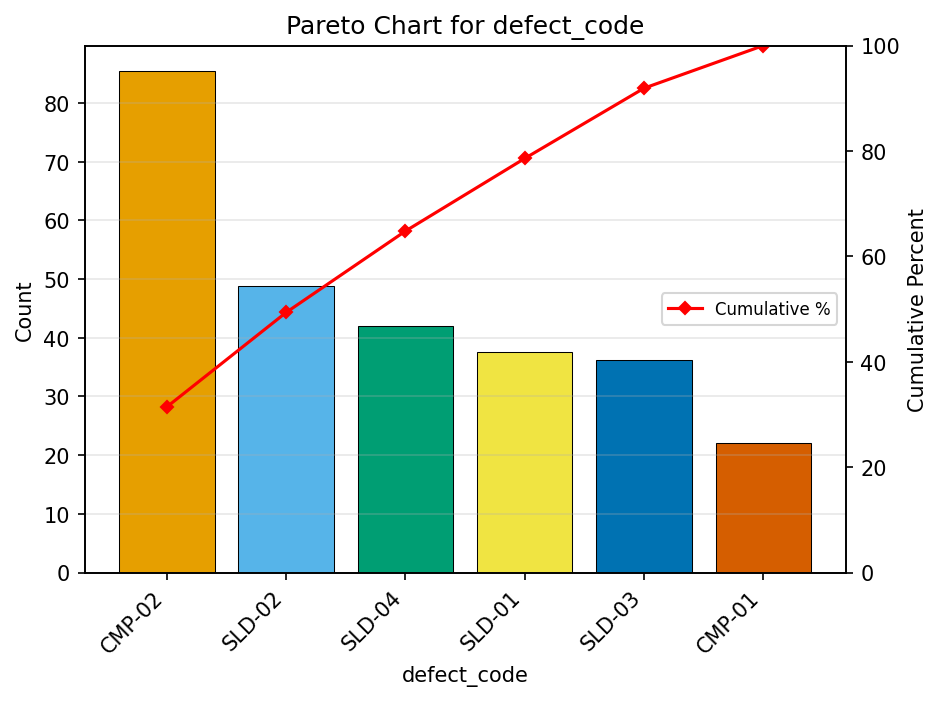

In [8]:
/* --------------------------------------------------------
   Step 3.C: Cost-weighted Pareto for LINE-C (solder/component, no Test failures).
   Subset to the line with a DATA step first, then chart —
   each line then renders as its own distinct Pareto.
   -------------------------------------------------------- */
data work.line_c;
    set work.defect_records;
    where production_line = 'LINE-C';
run;

proc pareto data=work.line_c;
    vbar defect_code / weight = rework_cost_usd
                       otherpct = 5;
    title 'Pareto Chart: Rework Cost by Defect Code — LINE-C';
run;

### Step 4 — Rank the vital-few cost drivers for kaizen targeting

To turn the cost Pareto into an action list, aggregate total rework cost per defect code with
`PROC MEANS` (`OUT=`), sort descending, and accumulate a cumulative percentage. The codes whose
running total reaches the **80% cutoff** are the *vital few* worth a dedicated kaizen event. Here
that set is **`TST-01`, `CMP-02`, `SLD-01`, `CMP-01`, `SLD-02`, and `SLD-04`** — six codes that
together drive ~80% of all rework spend.

In [9]:
/* --------------------------------------------------------
   Step 4: Aggregate cost per defect code, rank, and flag
   the vital few (cumulative cost <= 80%) for kaizen events.
   -------------------------------------------------------- */
proc means data=work.defect_records noprint nway;
    class defect_code defect_description;
    var rework_cost_usd;
    output out=work.cost_by_code(drop=_type_ _freq_)
           n=defect_count sum=total_cost;
run;

proc means data=work.defect_records noprint;
    var rework_cost_usd;
    output out=work.grand(drop=_type_ _freq_) sum=grand_total;
run;

proc sort data=work.cost_by_code;
    by descending total_cost;
run;

data work.vital_few;
    if _n_ = 1 then set work.grand;
    set work.cost_by_code;
    retain cum_cost 0;
    cum_cost + total_cost;
    cost_pct = 100 * total_cost / grand_total;
    cum_pct  = 100 * cum_cost  / grand_total;
    /* vital-few flag: include this code if the running total
       was still at or below 80% before adding it */
    if (cum_cost - total_cost) <= 0.80 * grand_total
        then vital_few = 'Yes';
        else vital_few = 'No ';
    drop grand_total cum_cost;
run;

proc print data=work.vital_few noobs;
    var defect_code defect_description defect_count
        total_cost cost_pct cum_pct vital_few;
    format total_cost cost_pct cum_pct 8.1;
    title 'Cost-Weighted Defect Ranking — Vital Few at 80% Cutoff';
run;

                                 Cost-Weighted Defect Ranking — Vital Few at 80% Cutoff                                 

DEFECT_CODE       DEFECT_DESCRIPTION  DEFECT_COUNT  TOTAL_COST  COST_PCT  CUM_PCT  VITAL_FEW
TST-01       Functional Fail - Power            10       450.0      25.3     25.3  Yes
CMP-02       Wrong Component                    10       285.0      16.0     41.3  Yes
SLD-01       Solder Bridge                      18       225.0      12.6     53.9  Yes
CMP-01       Missing Component                  10       220.0      12.4     66.3  Yes
SLD-02       Insufficient Solder                13       126.8       7.1     73.4  Yes
SLD-04       Cold Solder Joint                   8       112.0       6.3     79.7  Yes
SLD-03       Solder Ball                        12        87.0       4.9     84.6  Yes
CMP-03       Tombstone Component                 4        72.0       4.0     88.6  No
ASM-01       PCB Scratch                         7        56.0       3.1     91.7  No
ASM-

---

### Interpretation

The two Pareto views answer different questions, and reconciling them is the point of the
exercise:

- **By count**, the solder family dominates — `SLD-01`, `SLD-02`, `SLD-03` are 43% of defects.
  A team optimizing for *fewer defects* would attack solder paste and reflow first.
- **By cost**, priorities flip. `TST-01` (Functional Fail - Power) is the **largest single
  rework cost at 25.3%**, and the Test family carries the highest mean cost per repair (\$43.25)
  despite being only 12% of defects. A team optimizing for *cost avoidance* would target the
  functional-test failures first.

The by-line split sharpens the action plan. **LINE-B** is the clearest target: `TST-01` is
**38.6%** of its rework cost — a concentrated, line-specific excursion that a power-test or
firmware-load audit should resolve. **LINE-C** shows the opposite signature — solder-and-component
driven with **no Test failures** — pointing a reflow/paste audit at that line. **LINE-A** is a
broad mix with no single excursion.

**Recommended kaizen priority (from the vital-few table):** (1) audit LINE-B's functional-power
test path to drive down `TST-01`; (2) run a reflow/solder-paste review on LINE-C; (3) address
`CMP-01`/`CMP-02` component-placement defects, which appear in the vital few on every line.

---

### Method note

`PROC PARETO` renders the ranked bar chart with a cumulative-percentage overlay — the canonical
80/20 view. On the cost-weighted charts the left axis is the weighted rework total per defect
code (the right axis and red line are the cumulative percentage); read the left axis as rework
dollars. The **vital-few ranking table** in Step 4 is built with `PROC MEANS` (`OUT=`) and a
short DATA step rather than read back from the Pareto procedure, so the cumulative-percentage
cutoff and the kaizen flag are computed directly from the aggregated rework dollars. Each line in
Step 3 is charted from its own subset so all three production-line Paretos are distinct. All
figures quoted in this notebook are taken from the 100-record sample shown in the cell outputs
above.

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>